In [64]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import stats
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.utils.tensorboard import SummaryWriter

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance

In [29]:
writer = SummaryWriter(f"runs/training")

In [30]:
X, y = make_classification(n_samples=5000, n_features=20, n_classes=4, n_informative=4, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2)

trainval_dataset = TensorDataset(X_train_val, y_train_val)

<Axes: xlabel='None', ylabel='count'>

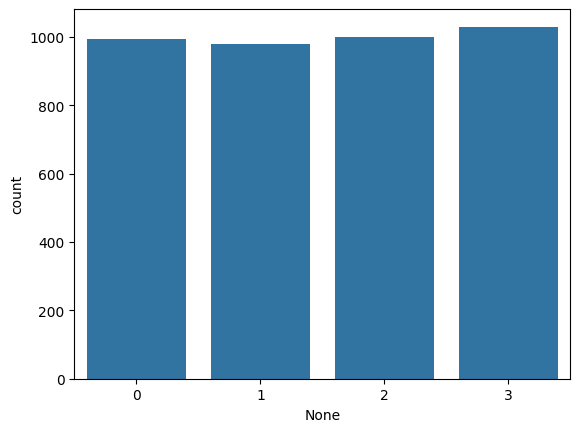

In [31]:
sns.countplot(x=y_train_val)

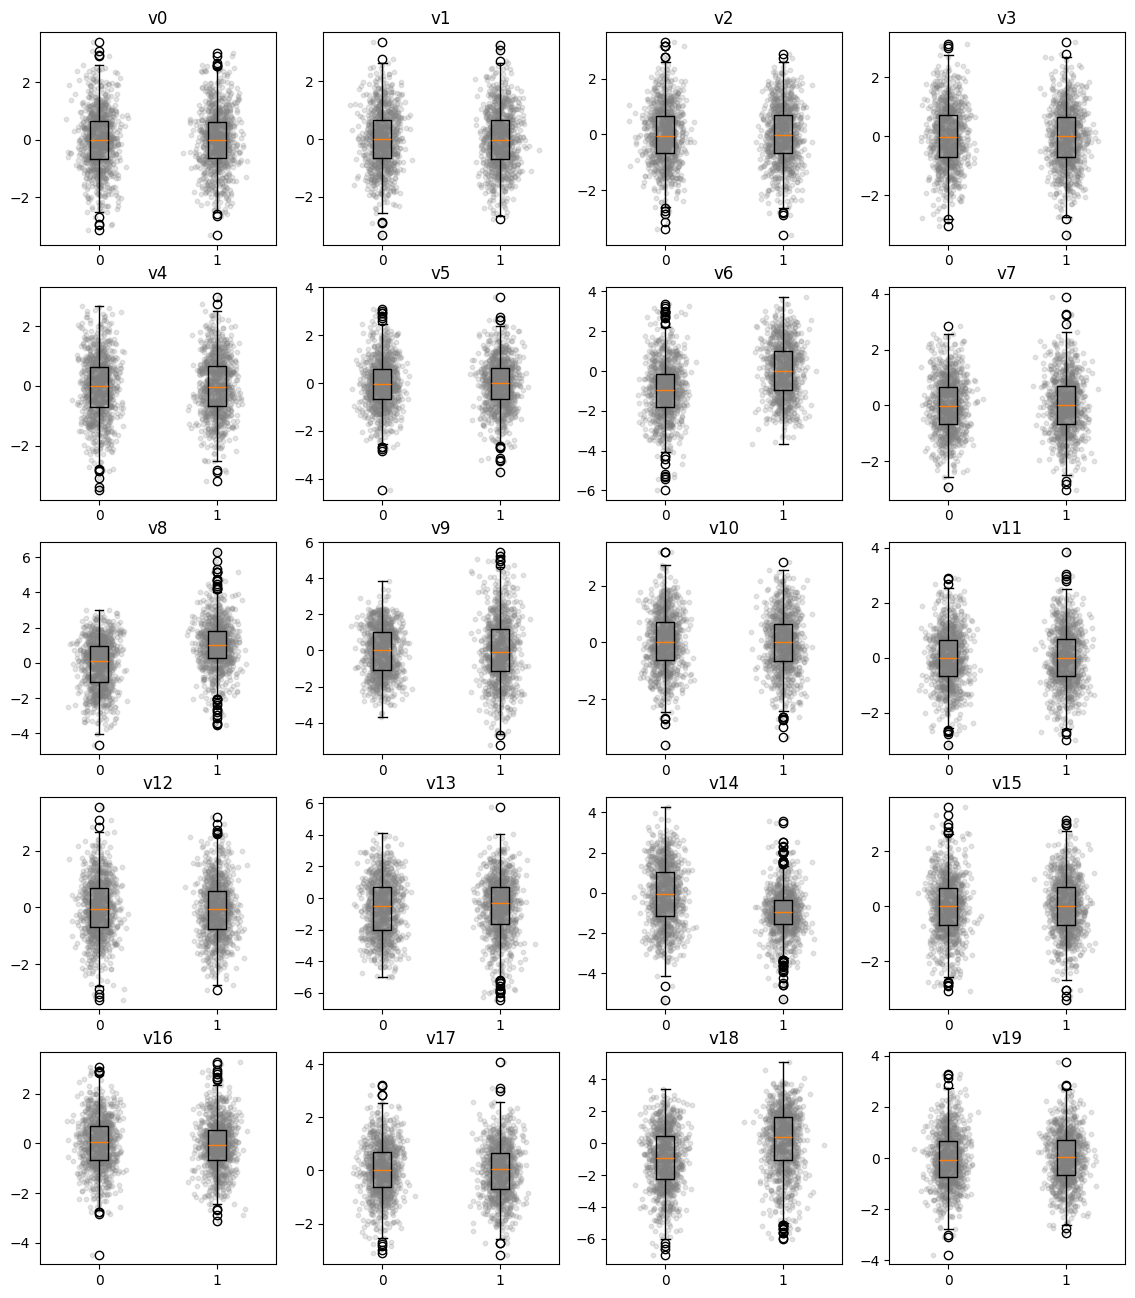

In [32]:
fig, axs = plt.subplots(5, 4, figsize=(14, 16))
axs = axs.flatten()

for feature_idx in range(20):
    x_y0 = X_train_val[y_train_val == 0, feature_idx].numpy()
    x_y1 = X_train_val[y_train_val == 1, feature_idx].numpy()

    x_0 = np.random.normal(1, 0.08, size=len(x_y0))
    x_1 = np.random.normal(2, 0.08, size=len(x_y1))
    axs[feature_idx].scatter(x_0, x_y0, alpha=0.2, color='gray', s=10)
    axs[feature_idx].scatter(x_1, x_y1, alpha=0.2, color='gray', s=10)
    axs[feature_idx].boxplot([x_y0, x_y1], tick_labels=["0", "1"])
    axs[feature_idx].set_title(f"v{feature_idx}")


In [33]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        HIDDEN_SIZE = 40

        self.model = nn.Sequential(
            nn.Linear(20, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, 4),
        )

        self.train_loss_per_epoch = None
        self.val_loss_per_epoch = None

    def forward(self, x):
        x = self.model(x)
        return x

In [34]:
def train_new_model(fold: int, epochs: int, train_loader: DataLoader, val_loader: DataLoader, save_dir: Path | None):
    model = MLP()
    optimizer = torch.optim.Adam(model.parameters())
    loss_fn = CrossEntropyLoss()

    print("Fold: ", fold)

    train_loss_per_epoch = np.zeros(epochs)
    val_loss_per_epoch = np.zeros(epochs)
    best_val_loss = 99999999.9

    for epoch in range(epochs):
        model.train()

        total_train_loss = 0.0
        total_val_loss = 0.0

        for data, target in train_loader:
            optimizer.zero_grad()

            output = model(data)
            loss = loss_fn(output, target)

            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                loss = loss_fn(output, target)
                total_val_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        print(f"{fold=} {epoch=} {avg_train_loss=:.3f} {avg_val_loss=:.3f}")

        train_loss_per_epoch[epoch] = avg_train_loss
        val_loss_per_epoch[epoch] = avg_val_loss

        writer.add_scalar(f"Loss/train/fold{fold}", avg_train_loss, epoch)
        writer.add_scalar(f"Loss/val/fold{fold}", avg_val_loss, epoch)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

            if save_dir:
                torch.save(model.state_dict(), save_dir / f"fold{fold}.pth")

    model.train_loss_per_epoch = train_loss_per_epoch
    model.val_loss_per_epoch = val_loss_per_epoch

    return model


In [35]:
def train_models_cv5(epochs: int, save_dir: Path | None) -> nn.ModuleList:
    cv = StratifiedKFold()

    val_losses = 0.0

    models = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_val, y_train_val)):
        train_loader = DataLoader(Subset(trainval_dataset, train_idx), batch_size=256, shuffle=True)
        val_loader = DataLoader(Subset(trainval_dataset, val_idx), batch_size=256, shuffle=True)
        model = train_new_model(fold, epochs, train_loader, val_loader, save_dir)

        best_val_loss = model.val_loss_per_epoch.min().item()
        val_losses += best_val_loss

        models.append(model)

    return nn.ModuleList(models)

In [36]:
save_dir = Path("checkpoints/best")
save_dir.mkdir(parents=True, exist_ok=True)
models = train_models_cv5(300, save_dir)

Fold:  0
fold=0 epoch=0 avg_train_loss=1.393 avg_val_loss=1.382
fold=0 epoch=1 avg_train_loss=1.341 avg_val_loss=1.327
fold=0 epoch=2 avg_train_loss=1.300 avg_val_loss=1.303
fold=0 epoch=3 avg_train_loss=1.263 avg_val_loss=1.252
fold=0 epoch=4 avg_train_loss=1.229 avg_val_loss=1.218
fold=0 epoch=5 avg_train_loss=1.197 avg_val_loss=1.206
fold=0 epoch=6 avg_train_loss=1.167 avg_val_loss=1.174
fold=0 epoch=7 avg_train_loss=1.139 avg_val_loss=1.120
fold=0 epoch=8 avg_train_loss=1.108 avg_val_loss=1.128
fold=0 epoch=9 avg_train_loss=1.083 avg_val_loss=1.096
fold=0 epoch=10 avg_train_loss=1.059 avg_val_loss=1.084
fold=0 epoch=11 avg_train_loss=1.033 avg_val_loss=1.067
fold=0 epoch=12 avg_train_loss=1.012 avg_val_loss=1.028
fold=0 epoch=13 avg_train_loss=0.990 avg_val_loss=1.026
fold=0 epoch=14 avg_train_loss=0.972 avg_val_loss=0.994
fold=0 epoch=15 avg_train_loss=0.948 avg_val_loss=0.971
fold=0 epoch=16 avg_train_loss=0.933 avg_val_loss=0.969
fold=0 epoch=17 avg_train_loss=0.911 avg_val_loss

In [48]:
class MyWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model: MLP):
        self.model = model
        self.model.eval()

    def fit(self, X, y):
        raise NotImplementedError()

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(X)
            logits = self.model(X)
            y_pred = torch.argmax(logits, dim=1)
            return y_pred

    def predict_proba(self, X):
        X = torch.tensor(X)
        return self.model(X)


In [52]:
clf = MyWrapper(models[0])
ind = range(6, 15)
clf.predict(X_train_val[ind]), y_train_val[ind]

/tmp/ipykernel_9403/1574938027.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X)


(tensor([2, 1, 0, 3, 3, 1, 1, 2, 0]), tensor([3, 1, 0, 3, 3, 3, 1, 3, 0]))

In [85]:
data = []
p_data = []
importances = []

for fold, model in enumerate(models):
    clf = MyWrapper(model)
    r = permutation_importance(clf, X_test, y_test, n_repeats=100, random_state=0)

    features_p_data = {}

    importances.append(r.importances)

    for feature_idx, importance in enumerate(r.importances_mean):
        feature_scores = r.importances[feature_idx]
        t_stat, p_val = stats.ttest_1samp(feature_scores, popmean=0, alternative='greater')

        data.append({
            'Model': f"fold{fold}",
            'Feature': f"v{feature_idx}",
            'Importance': importance,
            "p-value": p_val,
        })

        features_p_data[f"v{feature_idx}"] = f"{p_val:.3f}"

    p_data.append(features_p_data)

df_importance = pd.DataFrame(data)
p_df = pd.DataFrame(p_data, index=[f"fold{fold}" for fold in range(5)]).T
importances = np.array(importances)

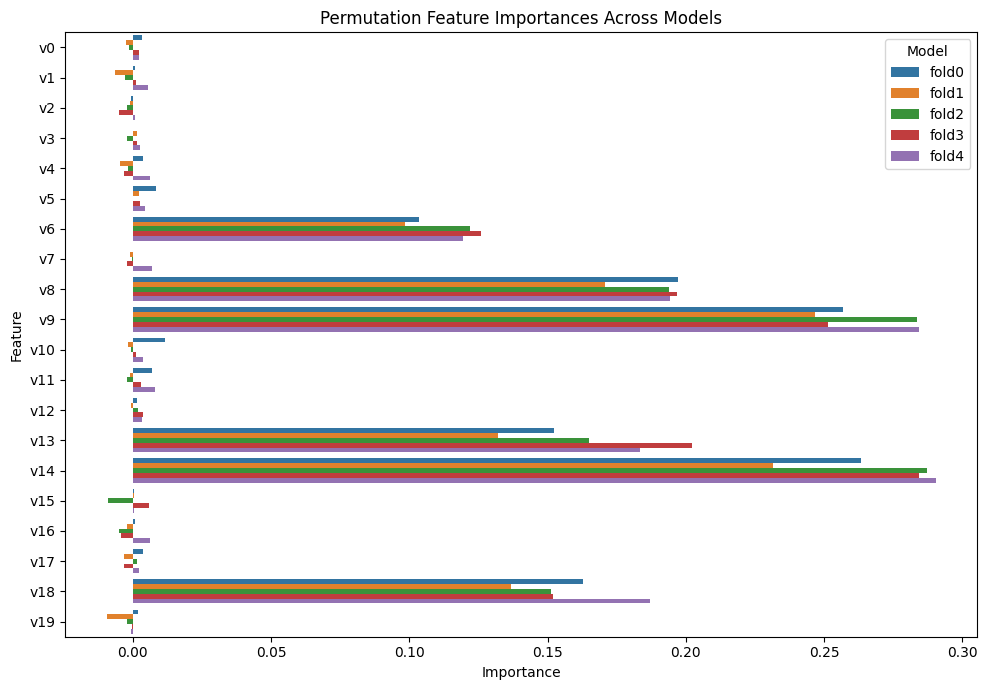

In [68]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=df_importance,
    x='Importance',
    y='Feature',
    hue='Model'
)

plt.title('Permutation Feature Importances Across Models')
plt.tight_layout()
plt.show()

In [92]:
importances.shape
per_feature_importances = importances.mean(axis=0)
per_feature_importances.shape

(20, 100)

In [107]:
per_feature_importances[0].mean(), per_feature_importances[0].std()

(np.float64(0.0008540000000000009), np.float64(0.0021776785805072353))

In [99]:
data = []
for feature_idx in range(20):
    t_stat, p_val = stats.ttest_1samp(per_feature_importances[feature_idx], popmean=0, alternative='greater')
    data.append({
        "p-value": f"{p_val:.4f}",
    })

df_feature_sign = pd.DataFrame(data, index=[f"v{i}" for i in range(20)])
df_feature_sign

,p-value
v0,0.0001
v1,0.9749
v2,1.0000
v3,0.0005
v4,0.4964
v5,0.0000
v6,0.0000
v7,0.0004
v8,0.0000
v9,0.0000


In [79]:
p_df

,fold0,fold1,fold2,fold3,fold4
v0,0.000,1.000,1.000,0.000,0.000
v1,0.028,1.000,1.000,0.014,0.000
v2,0.933,0.945,1.000,1.000,0.018
v3,0.279,0.003,1.000,0.000,0.000
v4,0.000,1.000,1.000,1.000,0.000
v5,0.000,0.000,0.348,0.000,0.000
v6,0.000,0.000,0.000,0.000,0.000
v7,0.327,0.992,0.872,1.000,0.000
v8,0.000,0.000,0.000,0.000,0.000
v9,0.000,0.000,0.000,0.000,0.000
